## Esercise 1

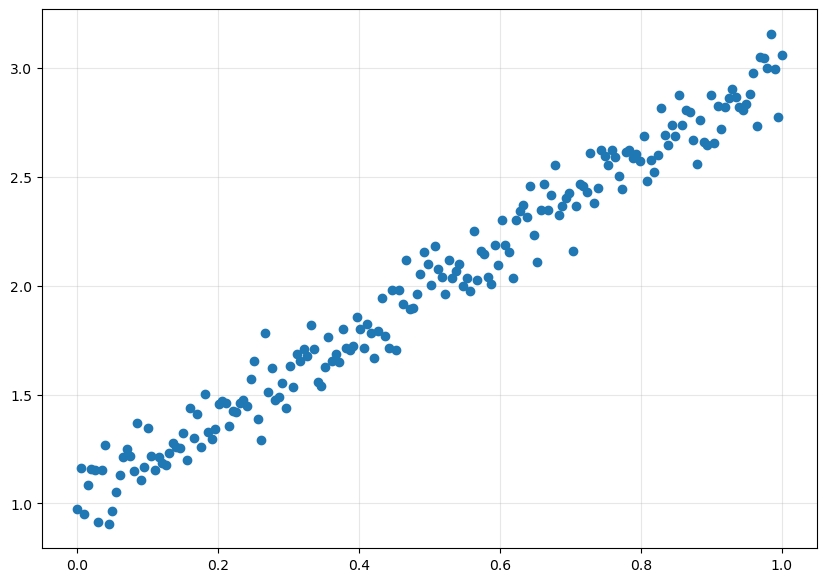

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

N = 200
X = np.linspace(0, 1, N) # equivalent to i/N
Y = 2 * X + 1 + np.random.normal(0, 0.1, size=X.shape)

# Visualize it
plt.figure(figsize=(10, 7))
plt.plot(X, Y, 'o')
plt.grid(alpha=0.3)
plt.show()

In [51]:
def l(Theta, X, Y):
    return np.mean(np.square(Theta[0] + Theta[1]*X - Y))  

def gradient(Theta, X, Y):
    N = len(X)
    g1 = 2 * np.mean(Theta[0] + Theta[1]*X - Y)
    g2 = 2 / N * np.dot(Theta[0] + Theta[1]*X - Y, X)
    return np.array([g1, g2])

def SGD(l, grad_l, X, Y, Theta0, lr=1e-2, batch_size=32, epochs=10):
    epoch_loss = []
    epoch_theta_history = []

    Theta = Theta0
    for epoch in range(epochs):
        shuffle_idx = np.random.permutation(len(X))
        N = len(X)

        for start in range(0, N, batch_size):
            batch_idx = shuffle_idx[start:start+batch_size]
            grad = grad_l(Theta, X[batch_idx], Y[batch_idx])
            Theta -= lr * grad

    
        epoch_loss.append(l(Theta, X, Y))
        epoch_theta_history.append(Theta.copy())

    return Theta, epoch, epoch_loss, epoch_theta_history

In [52]:
batch_sizes = [1,10,50,N]

results = pd.DataFrame([],columns=['batch_size', 'final_loss', 'epochs', 'Theta', 'epoch_loss', 'epoch_theta_history'])
for batch_size in batch_sizes:
    Theta0 = np.zeros((2,))
    Theta, epochs, epoch_loss, epoch_theta_history = SGD(l, gradient, X, Y, Theta0, lr=1e-2, batch_size=batch_size, epochs=1000)
    final_loss = l(Theta, X, Y)
    results.loc[len(results)] = [batch_size, final_loss, epochs, Theta, epoch_loss, epoch_theta_history]

display(results.sort_values(by='final_loss'))

,batch_size,final_loss,epochs,Theta,epoch_loss,epoch_theta_history
1,10,0.009338,999,"[1.0000264779279122, 1.9907244421300634]","[1.6238296969595214, 0.6492975405136511, 0.293...","[[0.6266611534773642, 0.37608168592802627], [0..."
0,1,0.009338,999,"[1.0002942640170862, 1.989591155079693]","[0.07876194313266088, 0.0501943478551761, 0.03...","[[1.4796480186895606, 1.0877069816180245], [1...."
2,50,0.009340,999,"[1.0033383695948814, 1.9852965669210274]","[3.543485397675789, 2.9060847224945974, 2.3868...","[[0.15359748677930435, 0.08997928769620724], [..."
3,200,0.016998,999,"[1.1607463437874432, 1.6914207191262975]","[4.115248943068265, 3.9148390918313876, 3.7244...","[[0.03991618767229272, 0.02330955031641145], [..."


In [53]:
batch_sizes = [1,10,50,N]

results = pd.DataFrame([],columns=['batch_size', 'final_loss', 'epochs', 'Theta', 'epoch_loss', 'epoch_theta_history'])
for batch_size in batch_sizes:
    Theta0 = np.zeros((2,))
    Theta, epochs, epoch_loss, epoch_theta_history = SGD(l, gradient, X, Y, Theta0, lr=1e-2, batch_size=batch_size, epochs=1000)
    final_loss = l(Theta, X, Y)
    results.loc[len(results)] = [batch_size, final_loss, epochs, Theta, epoch_loss, epoch_theta_history]

display(results.sort_values(by='final_loss'))

,batch_size,final_loss,epochs,Theta,epoch_loss,epoch_theta_history
1,10,0.009337,999,"[1.000590584210248, 1.9910180489474933]","[1.6174991301322583, 0.6458947058121107, 0.296...","[[0.6302340950754676, 0.3746355237924033], [1...."
2,50,0.009340,999,"[1.0033375069320827, 1.9853011934600004]","[3.543454140165084, 2.9057023698574485, 2.3867...","[[0.15363383858826235, 0.08993233618990354], [..."
0,1,0.009405,999,"[1.0073250852136002, 1.9933544559224252]","[0.07470305473664957, 0.04708201844456886, 0.0...","[[1.4240686292478144, 1.11136540564849], [1.33..."
3,200,0.016998,999,"[1.1607463437874432, 1.6914207191262975]","[4.115248943068265, 3.9148390918313876, 3.7244...","[[0.03991618767229272, 0.023309550316411458], ..."


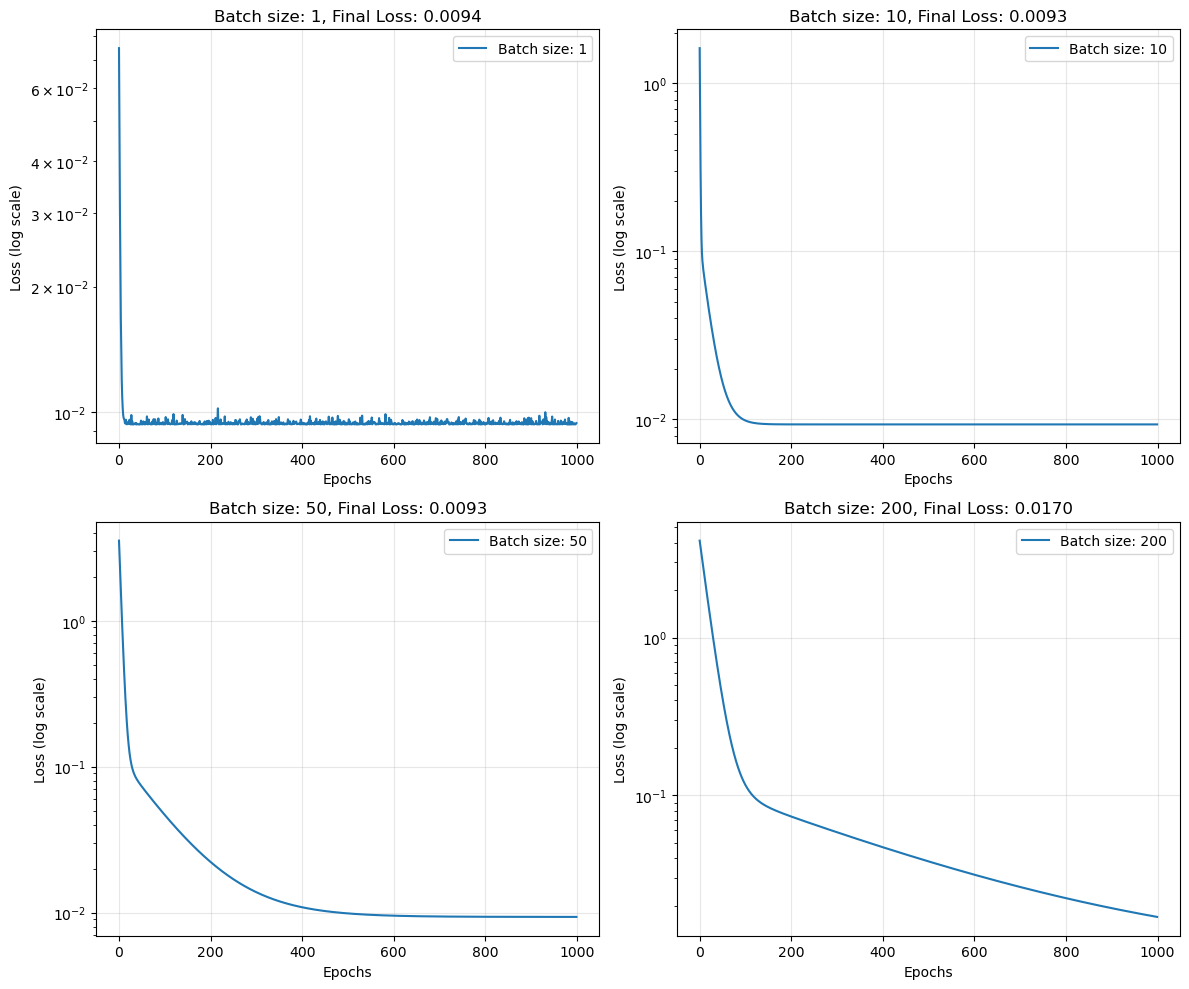

In [56]:
n_plots = len(results)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()
for index, row in results.iterrows():
    axes[index].plot(row['epoch_loss'], label=f"Batch size: {row['batch_size']}")
    axes[index].set_yscale('log')
    axes[index].set_xlabel("Epochs")
    axes[index].set_ylabel("Loss (log scale)")
    axes[index].legend()
    axes[index].grid(alpha=0.3)
    axes[index].set_title(f"Batch size: {row['batch_size']}, Final Loss: {row['final_loss']:.4f}")

plt.tight_layout()
plt.show()

In [61]:
def loss_levelsets(X_data, Y_data, theta_0_lim=(0.5,1.5), theta_1_lim=(1.5,2.5), ngrid=400, 
                   ncontours=12, title=None):
    theta_0_vals = np.linspace(theta_0_lim[0], theta_0_lim[1], ngrid)
    theta_1_vals = np.linspace(theta_1_lim[0], theta_1_lim[1], ngrid)
    Theta0_grid, Theta1_grid = np.meshgrid(theta_0_vals, theta_1_vals)
    
    Z = np.mean((Theta0_grid[:,:,np.newaxis] + Theta1_grid[:,:,np.newaxis] * X_data - Y_data)**2, axis=2)
    
    cs = plt.contour(Theta0_grid, Theta1_grid, Z, levels=ncontours)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.axhline(0, lw=0.5, color='k')
    plt.axvline(0, lw=0.5, color='k')
    plt.gca().set_aspect('equal', 'box')
    if title:
        plt.title(title)
    plt.xlabel(r'$\theta_0$ (bias)')
    plt.ylabel(r'$\theta_1$ (slope)')
    plt.grid(alpha=0.2)

    # ensure axis bounds are set so subsequent plotting is clipped to these limits
    plt.xlim(theta_0_lim)
    plt.ylim(theta_1_lim)

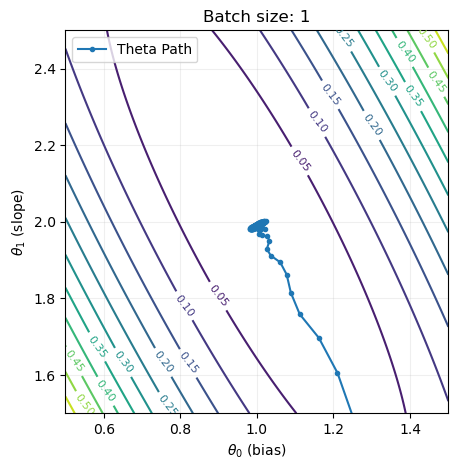

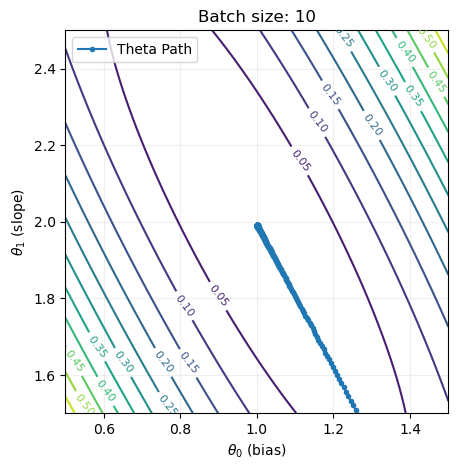

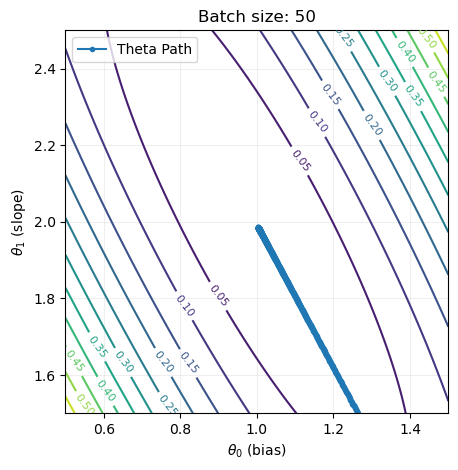

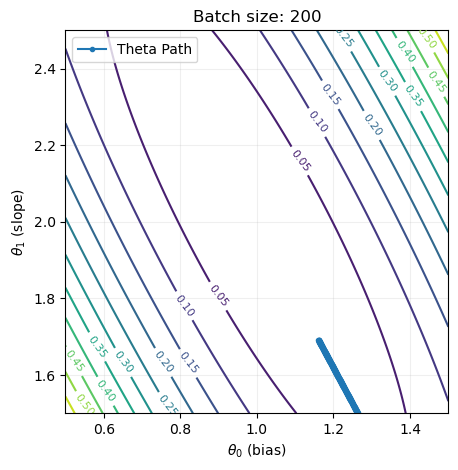

In [62]:
# plot epoch theta history
for index, row in results.iterrows():
    loss_levelsets(X, Y, title=f"Batch size: {row['batch_size']}")
    plt.plot(
        [theta[0] for theta in row['epoch_theta_history']],
        [theta[1] for theta in row['epoch_theta_history']],
        '-o', markersize=3, label='Theta Path'
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


## Ex 2

In [67]:
fixed_theta = np.array([1.0, 2.0])

batch_sizes = [1,5,20,N]

monte_carlo_variance_estimates = pd.DataFrame([], columns=['batch_size', 'grad_mean', 'grad_variance'])

for batch_size in batch_sizes:
    n_of_iterations = 100
    grads = []
    for i in range(n_of_iterations):
        shuffle_idx = np.random.permutation(len(X))   
        batch_idx = shuffle_idx[:batch_size]
        grad = gradient(fixed_theta, X[batch_idx], Y[batch_idx])
        grads.append(grad)
    grads = np.array(grads)
    grad_mean =  1/n_of_iterations * np.sum(grads, axis=0)  
    grad_variance = 1/n_of_iterations * np.sum(np.linalg.norm(grads - grad_mean, axis=1)**2) 
    monte_carlo_variance_estimates.loc[len(monte_carlo_variance_estimates)] = [batch_size, grad_mean, grad_variance]

display(monte_carlo_variance_estimates.sort_values(by='grad_variance', ascending=False))

,batch_size,grad_mean,grad_variance
0,1,"[-0.018413396920066903, -0.004024914804177703]",4.847677e-02
1,5,"[0.0036036821831810983, 0.003960354327378306]",9.928982e-03
2,20,"[0.008634606778280839, 0.006245152222417212]",2.729504e-03
3,200,"[0.008381232770727734, 0.005728385444281781]",2.287869e-34


## Ex 3

In [148]:
def l(Theta):
    return (1 - Theta[0])**2 + 10 * (Theta[1] - Theta[0]**2)**2

def gradient(Theta):
    g1 = -2 * (1 - Theta[0]) - 40 * Theta[0] * (Theta[1] - Theta[0]**2)
    g2 = 20 * (Theta[1] - Theta[0]**2)
    return np.array([g1, g2])

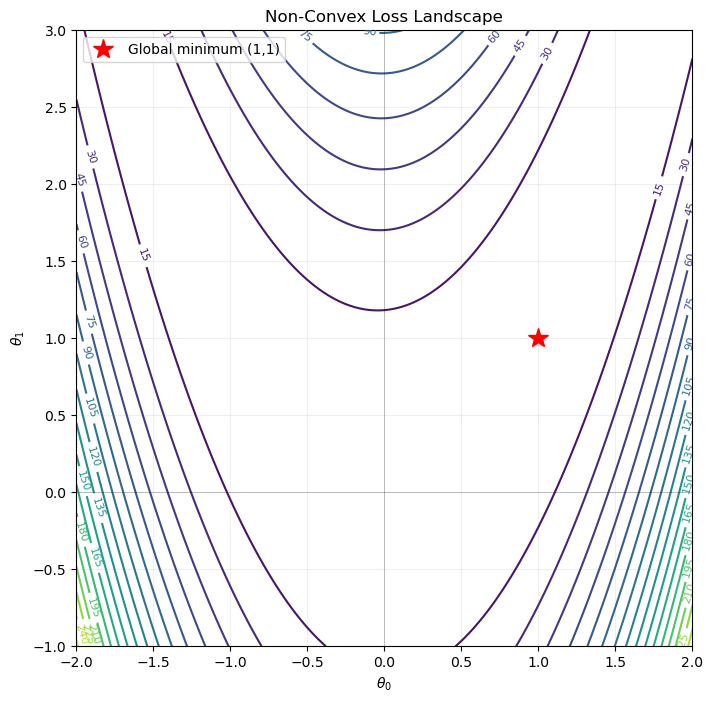

In [149]:
# Visualize the loss landscape
def plot_nonconvex_levelsets(theta_0_lim=(-2, 2), theta_1_lim=(-1, 3), ngrid=400, ncontours=20, title=None):
    theta_0_vals = np.linspace(theta_0_lim[0], theta_0_lim[1], ngrid)
    theta_1_vals = np.linspace(theta_1_lim[0], theta_1_lim[1], ngrid)
    Theta0_grid, Theta1_grid = np.meshgrid(theta_0_vals, theta_1_vals)
    
    # Compute loss for each grid point
    Z = (1 - Theta0_grid)**2 + 10 * (Theta1_grid - Theta0_grid**2)**2
    
    cs = plt.contour(Theta0_grid, Theta1_grid, Z, levels=ncontours, cmap='viridis')
    plt.clabel(cs, inline=True, fontsize=8)
    
    # Mark the global minimum at (1, 1)
    plt.plot(1, 1, 'r*', markersize=15, label='Global minimum (1,1)')
    
    plt.axhline(0, lw=0.5, color='k', alpha=0.3)
    plt.axvline(0, lw=0.5, color='k', alpha=0.3)
    plt.gca().set_aspect('equal', 'box')
    if title:
        plt.title(title)
    plt.xlabel(r'$\theta_0$')
    plt.ylabel(r'$\theta_1$')
    plt.grid(alpha=0.2)
    plt.xlim(theta_0_lim)
    plt.ylim(theta_1_lim)
    plt.legend()

# Plot the landscape
plt.figure(figsize=(10, 8))
plot_nonconvex_levelsets(title='Non-Convex Loss Landscape')
plt.show()

In [150]:
def SGD_with_noise(L, grad_L, theta_0, lr=1e-3, noise_level=0.1, epochs=1000):
    """
    SGD with simulated gradient noise.
    
    At each iteration, the gradient batch is:
        g_batch = grad_L(theta) + N(0, noise_level^2 * I)
    """
    theta = theta_0.copy()
    theta_history = [theta.copy()]
    loss_history = [L(theta)]
    
    for epoch in range(epochs):
        # Compute true gradient
        g_true = grad_L(theta)
        
        # Add Gaussian noise to simulate stochastic gradient
        noise = np.random.normal(0, noise_level, size=theta.shape)
        g_batch = g_true + noise
        
        # SGD update
        theta = theta - lr * g_batch
        
        theta_history.append(theta.copy())
        loss_history.append(L(theta))

        if np.linalg.norm(theta) > 1e5:
            break
    
    return theta, theta_history, loss_history

In [151]:
from sklearn.model_selection import ParameterGrid

starting_theta = np.array([0.0, 0.0])
etas = [0.1, 0.01, 0.001, 0.0001]
noise_levels = [0.05, 0.1, 0.5, 1.0]

param_grid = ParameterGrid({'eta': etas, 'noise_level': noise_levels})
configurations = list(param_grid)

In [152]:
SGD_simulations = pd.DataFrame([], columns=['eta', 'noise_level', 'final_theta', 'final_loss', 'theta_history', 'loss_history'])

for config in configurations:
    eta = config['eta']
    noise_level = config['noise_level']
    
    theta0 = np.array([0.0, 0.0])
    theta_final, theta_history, loss_history = SGD_with_noise(
        L=l, grad_L=gradient, theta_0=theta0, lr=eta, noise_level=noise_level, epochs=5000
    )
    
    final_loss = l(theta_final)
    SGD_simulations.loc[len(SGD_simulations)] = [eta, noise_level, theta_final, final_loss, theta_history, loss_history]

display(SGD_simulations[['eta', 'noise_level', 'final_loss','final_theta']].sort_values(by='final_loss'))

,eta,noise_level,final_loss,final_theta
4,0.0100,0.05,2.483433e-06,"[0.9993527472371069, 0.9991602807132547]"
7,0.0100,1.00,1.415031e-05,"[0.9964593268540429, 0.9933329288462782]"
5,0.0100,0.10,1.028877e-04,"[0.9942068940532723, 0.9858143343472968]"
8,0.0010,0.05,2.081623e-03,"[0.9548397955541501, 0.9096652915086354]"
9,0.0010,0.10,2.311193e-03,"[0.9522934948199054, 0.9049845327762263]"
11,0.0010,1.00,2.971987e-03,"[0.9474462657517458, 0.8930708491599736]"
10,0.0010,0.50,3.091505e-03,"[0.945466724575669, 0.8904776518482728]"
6,0.0100,0.50,3.313533e-03,"[0.9563617715570617, 0.9264989699987497]"
15,0.0001,1.00,2.373437e-01,"[0.5191118203895859, 0.24479856125059124]"
14,0.0001,0.50,2.442261e-01,"[0.5124300386806406, 0.23708632112870257]"


In [153]:
SGD_simulations = pd.DataFrame([], columns=['eta', 'noise_level', 'final_theta', 'final_loss', 'theta_history', 'loss_history'])

for config in configurations:
    eta = config['eta']
    noise_level = config['noise_level']
    
    theta0 = np.array([0.0, 0.0])
    theta_final, theta_history, loss_history = SGD_with_noise(
        L=l, grad_L=gradient, theta_0=theta0, lr=eta, noise_level=noise_level, epochs=5000
    )
    
    final_loss = l(theta_final)
    SGD_simulations.loc[len(SGD_simulations)] = [eta, noise_level, theta_final, final_loss, theta_history, loss_history]

display(SGD_simulations[['eta', 'noise_level', 'final_loss','final_theta']].sort_values(by='final_loss'))

,eta,noise_level,final_loss,final_theta
4,0.0100,0.05,1.960809e-06,"[1.0008450217945921, 1.0013376645194427]"
5,0.0100,0.10,1.387955e-04,"[0.9893430422981999, 0.977211424222559]"
7,0.0100,1.00,8.460344e-04,"[1.0274526249284883, 1.0586984329708622]"
9,0.0010,0.10,2.142502e-03,"[0.9539506587397961, 0.9085399759115271]"
8,0.0010,0.05,2.146672e-03,"[0.9540498558604141, 0.9083334533767428]"
10,0.0010,0.50,2.504068e-03,"[0.9508038150158337, 0.9011330131743664]"
6,0.0100,0.50,3.023535e-03,"[1.0215719507848282, 1.027614921525411]"
11,0.0010,1.00,3.633396e-03,"[0.9486799198812581, 0.9099918181524663]"
14,0.0001,0.50,2.457068e-01,"[0.5112862078306836, 0.23521118813538197]"
12,0.0001,0.05,2.469200e-01,"[0.5094870721551231, 0.23444330066727756]"


In [ ]:
# Plot trajectories for all configurations
n_plots = len(configurations)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for ax, (idx, row) in zip(axes, SGD_simulations.iterrows()):
    eta = row['eta']
    noise_level = row['noise_level']
    theta_history = np.array(row['theta_history'])
    
    # Draw level sets
    xs = np.linspace(-2, 2, 400)
    ys = np.linspace(-1, 3, 400)
    X_grid, Y_grid = np.meshgrid(xs, ys)
    Z = (1 - X_grid)**2 + 10 * (Y_grid - X_grid**2)**2
    cs = ax.contour(X_grid, Y_grid, Z, levels=20, cmap='viridis', alpha=0.6)
    ax.clabel(cs, inline=True, fontsize=7)
    
    # Plot trajectory
    ax.plot(theta_history[:, 0], theta_history[:, 1], 'r-', alpha=0.7, linewidth=1.5)
    ax.scatter(theta_history[0, 0], theta_history[0, 1], color='black', s=60, marker='o', zorder=5, label='Start')
    ax.scatter(1, 1, color='green', s=80, marker='*', zorder=5, label='Global min (1,1)')
    ax.scatter(theta_history[-1, 0], theta_history[-1, 1], color='blue', s=60, marker='s', zorder=5, label='End')
    
    ax.legend(loc='upper right', fontsize=7)
    ax.set_title(f'η={eta:.5f}, noise={noise_level:.2f}\nFinal Loss={row["final_loss"]:.4f}', fontsize=9)
    ax.set_xlabel(r'$\theta_0$', fontsize=9)
    ax.set_ylabel(r'$\theta_1$', fontsize=9)
    ax.grid(alpha=0.2)
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1, 3)

# Hide empty subplots
for ax in axes[n_plots:]:
    ax.axis('off')

plt.tight_layout()
plt.show()